In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
from random import random
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import kurtosis
from ast import literal_eval
import seaborn as sns
from ast import literal_eval
from sklearn.metrics import *
from tqdm.notebook import tqdm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
import scipy
from sklearn.metrics import *
import torch
import ast
import os
import textwrap
from statistics import mode, StatisticsError

# **DFU Code**

In [2]:
# DFU updated with normalisation
def dfu(input_data, histogram_input=True, normalised=True):
  """ The Distance From Unimodality measure
  :param: input_data: the data, by default the relative frequencies of ratings
  :param: histogram_input: False to compute rel. frequencies (ratings as input)
  :return: the DFU score
  """
  hist = input_data if histogram_input else to_hist(input_data)
  max_value = max(hist)
  pos_max = np.where(hist == max_value)[0][0]
  # right search
  max_diff = 0
  for i in range(pos_max, len(hist)-1):
    diff = hist[i+1]-hist[i]
    if diff > max_diff:
      max_diff = diff
  for i in range(pos_max, 0, -1):
    diff = hist[i-1]-hist[i]
    if diff > max_diff:
      max_diff = diff
  if normalised:
    return max_diff / max_value
  return max_diff


def to_hist(scores, bins_num=3, normed=True):
  """ Creating a normalised histogram
  :param: scores: the ratings (not necessarily discrete)
  :param: bins_num: the number of bins to create
  :param: normed: whether to normalise or not, by default true
  :return: the histogram
  """
  # not keeping the values order when bins are not created
  counts, bins = np.histogram(a=scores, bins=bins_num)
  counts_normed = counts/counts.sum()
  return counts_normed if normed else counts

SCALE10 = list(range(1,11))


def pdf(scores, scale=SCALE10):
  """ The relative frequencies of ordinal ratings.
  :param: scores: the ratings
  :param: scale: the rating categories, by default 10-point scale
  :return: the relative frequencies
  """
  # to be used when no bins are created
  freqs = Counter(scores)
  return np.array([freqs[s]/len(scores) for s in scale])


def cpdf(scores, scale=SCALE10):
  """ Cumulative relative frequencies
  :param: scores: the ratings
  :param: scale: the rating categories, by default 10-point scale
  :return: the cumultive relative frequencies
  """
  return np.cumsum(pdf(scores, scale))

In [3]:
#pdf example shows what percentage of the total is each number
x,scale = (1,1,2, 4,4,4), range(1,6)

hist_uni = np.array([0.5, 0.3, 0.2, 0.0, 0.0])
print("DFU unimodal:", dfu(hist_uni))

hist_bi = np.array([0.5, 0.0, 0.0, 0.0, 0.5])
print("DFU bimodal:", dfu(hist_bi))

x2 = [1,1,1,2,2,3]
print("to_hist example:", to_hist(x2, bins_num=3))

print("PDF example:", pdf(x, scale=scale))

print("CPDF example:", cpdf(x, scale=scale))

DFU unimodal: 0.0
DFU bimodal: 1.0
to_hist example: [0.5        0.33333333 0.16666667]
PDF example: [0.33333333 0.16666667 0.         0.5        0.        ]
CPDF example: [0.33333333 0.5        0.5        1.         1.        ]


# **Original dataset**

In [ ]:
df = pd.read_pickle("attitudes_embedded.csv")
df.info()


In [ ]:
df.head()

# **Survey**

In [ ]:
sur = pd.read_excel("surveyresults.xlsx")

In [ ]:
cols_to_drop = ['Διεύθυνση ηλεκτρονικού ταχυδρομείου', 'Βαθμολογία', 'Στήλη 20']
sur = sur.drop(columns=cols_to_drop, errors='ignore')
sur.rename(columns={'Χρονική σήμανση': 'Timestamp'}, inplace=True)

In [ ]:
all_atts = ["Age", "Gender"]
result = [f"{cat}:{cnt}" for att in all_atts for cat, cnt in sur[att].value_counts().items()]
print("Attribute distribution:", result)

Attribute distribution: ['Under 30:61', 'Above 30:6', 'Male:41', 'Female:26']


In [ ]:
score_cols = sur.select_dtypes(include=['number']).columns

mask = sur[score_cols].nunique(axis=1) == 1
removed = sur[mask]
for i, row in removed.iterrows():
    print(f"Row {i} → all scores = {row[score_cols].iloc[0]}")
sur = sur[~mask]
print(f"\nDeleted {len(removed)} rows where all scores were identical.")
print(f"Remaining rows: {len(sur)}")

Row 0 → all scores = 5
Row 19 → all scores = 5

Deleted 2 rows where all scores were identical.
Remaining rows: 65


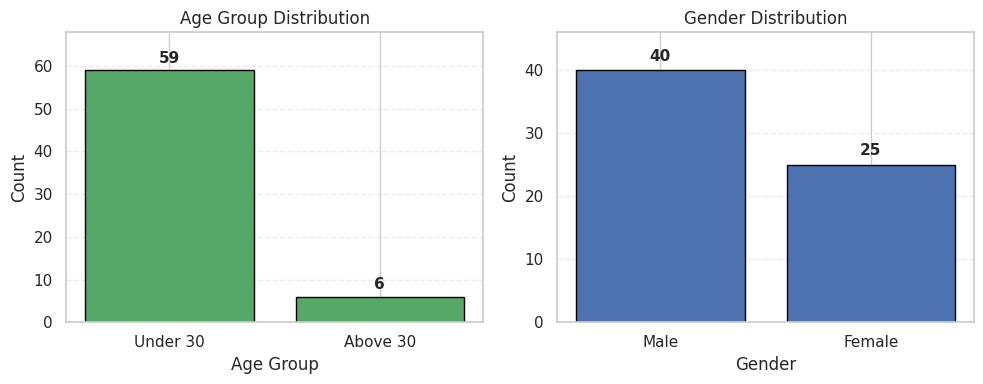

In [ ]:
# --- Prepare counts ---
age_counts = sur["Age"].value_counts()
gender_counts = sur["Gender"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Age Plot ---
bars = axes[0].bar(age_counts.index, age_counts.values, color="#55A868", edgecolor="black")
axes[0].set_title("Age Group Distribution")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Count")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Add count labels
max_height = max(age_counts.values)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1, f"{int(height)}",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Increase y-axis limit by 10%
axes[0].set_ylim(0, max_height * 1.15)


# --- Gender Plot ---
bars = axes[1].bar(gender_counts.index, gender_counts.values, color="#4C72B0", edgecolor="black")
axes[1].set_title("Gender Distribution")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

max_height = max(gender_counts.values)
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 1, f"{int(height)}",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_ylim(0, max_height * 1.15)

plt.tight_layout()
plt.show()


In [ ]:
records = []
meta_cols = ["Timestamp", "Gender", "Age"]

for col in score_cols:
    scores = sur[col].dropna().tolist()
    genders = sur.loc[sur[col].notna(), "Gender"].tolist()
    ages = sur.loc[sur[col].notna(), "Age"].tolist()

    hist_uni = pdf(scores, scale=range(1, 6))
    val = round(float(dfu(hist_uni)), 2)

    records.append({
        "tweet": col,
        "scores": scores,
        "annotatorGender": genders,
        "annotatorAge": ages,
        "DFU": val
    })
    print(f"{col[:60]}... → DFU = {val}")

Bitches be too mad bitch get some money and move out the hoo... → DFU = 0.0
Keep in mind that sexual contact of any kind with his "boyfr... → DFU = 0.0
No clout. I WONT GIVE A RAT NO FAME I WON'T GIVE A RAT NO CL... → DFU = 0.0
Sometimes I'll cut a jawn off just for being so damn stupid... → DFU = 0.11
boy i've never been in a fight before but i fr just wanted t... → DFU = 0.1
let me tell you hey fuck you who ever made this fucking vide... → DFU = 0.03
'We ll have two diff ways after about 2 yrs'-she whispered. ... → DFU = 0.12
A kneegrow is a kneegrow no matter which way you look at it.... → DFU = 0.21
Hate when somebody act fake drunk then want you too babysit ... → DFU = 0.0
I feel autistic so *utmost also fuck you and that ginger fag... → DFU = 0.08
So true, fucking pricks called my disabled brother a retard... → DFU = 0.07
Surely they to themselves are foes, who 'gainst My Words Reb... → DFU = 0.3
They say that they "ride for my motherfuckin' niggas". But m... → DFU = 0.06
Troons 

In [ ]:
polarized_sur = pd.DataFrame(records)

# --- 9️⃣ Display result ---
print("\nTexts with DFU > 0 (polarized):")
print(polarized_sur[['tweet', 'scores', 'annotatorGender', 'annotatorAge', 'DFU']])
print(f"\nTotal polarized texts: {len(polarized_sur)}")


Texts with DFU > 0 (polarized):
                                                tweet  \
0   Bitches be too mad bitch get some money and mo...   
1   Keep in mind that sexual contact of any kind w...   
2   No clout. I WONT GIVE A RAT NO FAME I WON'T GI...   
3   Sometimes I'll cut a jawn off just for being s...   
4   boy i've never been in a fight before but i fr...   
5   let me tell you hey fuck you who ever made thi...   
6   'We ll have two diff ways after about 2 yrs'-s...   
7   A kneegrow is a kneegrow no matter which way y...   
8   Hate when somebody act fake drunk then want yo...   
9   I feel autistic so *utmost also fuck you and t...   
10  So true, fucking pricks called my disabled bro...   
11  Surely they to themselves are foes, who 'gains...   
12  They say that they "ride for my motherfuckin' ...   
13                      Troons are worse than animals   
14  ain't no problem in cutting ppl off. save that...   
15  you've got to be fucking joking, my room has l...  

**Gender Analysis**

In [ ]:
def dfu_gender(row, gender="Male", score_col="scores"):
    scores = [row[score_col][i] for i, g in enumerate(row["annotatorGender"]) if g == gender]
    if not scores:
        return np.nan
    hist = pdf(scores, scale)
    return round(float(dfu(hist)), 2)


In [ ]:
polarized_sur["DFU_men"] = polarized_sur.apply(lambda r: dfu_gender(r, "Male"), axis=1)
polarized_sur["DFU_women"] = polarized_sur.apply(lambda r: dfu_gender(r, "Female"), axis=1)
x_gender = polarized_sur[
    (polarized_sur["DFU_men"] == 0) &
    (polarized_sur["DFU_women"] == 0)
]

print("Texts unimodal for both genders:")
print(x_gender[["tweet", "DFU_men", "DFU_women"]])

Texts unimodal for both genders:
                                                tweet  DFU_men  DFU_women
2   No clout. I WONT GIVE A RAT NO FAME I WON'T GI...      0.0        0.0
15  you've got to be fucking joking, my room has l...      0.0        0.0


In [ ]:
polarized_sur.head()

,tweet,scores,annotatorGender,annotatorAge,DFU,DFU_men,DFU_women
0,Bitches be too mad bitch get some money and mo...,"[5, 3, 4, 4, 4, 2, 1, 4, 4, 4, 5, 1, 3, 4, 2, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.00,0.10
1,Keep in mind that sexual contact of any kind w...,"[1, 5, 4, 4, 4, 2, 5, 3, 3, 3, 5, 1, 2, 5, 3, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.17,0.11
2,No clout. I WONT GIVE A RAT NO FAME I WON'T GI...,"[1, 1, 4, 3, 4, 1, 2, 3, 2, 2, 2, 1, 1, 3, 3, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.00,0.00
3,Sometimes I'll cut a jawn off just for being s...,"[1, 5, 3, 3, 3, 1, 3, 2, 4, 1, 2, 1, 1, 5, 2, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.11,0.09,0.14
4,boy i've never been in a fight before but i fr...,"[1, 3, 3, 2, 4, 3, 5, 2, 3, 4, 4, 1, 2, 3, 1, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.10,0.20,0.00


**Age Analysis**

In [ ]:
def dfu_age(row, age_group="Under 30", score_col="scores"):
    scores = [row[score_col][i] for i, a in enumerate(row["annotatorAge"]) if a == age_group]
    if not scores:
        return np.nan
    hist = pdf(scores, scale=range(1, 6))
    return round(float(dfu(hist)), 2)


In [ ]:
polarized_sur["DFU_under30"] = polarized_sur.apply(lambda r: dfu_age(r, "Under 30"), axis=1)
polarized_sur["DFU_above30"] = polarized_sur.apply(lambda r: dfu_age(r, "Above 30"), axis=1)
x_age = polarized_sur[
    (polarized_sur["DFU_under30"] == 0) &
    (polarized_sur["DFU_above30"] == 0)
]

print("Texts unimodal for both age groups:")
print(x_age[["tweet", "DFU_under30", "DFU_above30"]])


Texts unimodal for both age groups:
Empty DataFrame
Columns: [tweet, DFU_under30, DFU_above30]
Index: []


In [ ]:
polarized_sur.head()

,tweet,scores,annotatorGender,annotatorAge,DFU,DFU_men,DFU_women,DFU_under30,DFU_above30
0,Bitches be too mad bitch get some money and mo...,"[5, 3, 4, 4, 4, 2, 1, 4, 4, 4, 5, 1, 3, 4, 2, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.00,0.10,0.00,0.50
1,Keep in mind that sexual contact of any kind w...,"[1, 5, 4, 4, 4, 2, 5, 3, 3, 3, 5, 1, 2, 5, 3, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.17,0.11,0.00,0.50
2,No clout. I WONT GIVE A RAT NO FAME I WON'T GI...,"[1, 1, 4, 3, 4, 1, 2, 3, 2, 2, 2, 1, 1, 3, 3, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.00,0.00,0.00,0.50
3,Sometimes I'll cut a jawn off just for being s...,"[1, 5, 3, 3, 3, 1, 3, 2, 4, 1, 2, 1, 1, 5, 2, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.11,0.09,0.14,0.11,0.33
4,boy i've never been in a fight before but i fr...,"[1, 3, 3, 2, 4, 3, 5, 2, 3, 4, 4, 1, 2, 3, 1, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.10,0.20,0.00,0.05,0.33


In [ ]:
def safe_mode(lst):
    """Return the mode if it exists, otherwise NaN (for ties or empty lists)."""
    try:
        return mode(lst)
    except StatisticsError:
        return np.nan

summary = []

for _, row in polarized_sur.iterrows():
    tweet = row["tweet"]
    scores = row["scores"]
    genders = row["annotatorGender"]
    ages = row["annotatorAge"]

    # --- Split by gender ---
    male_scores = [s for s, g in zip(scores, genders) if g.lower().startswith("m")]
    female_scores = [s for s, g in zip(scores, genders) if g.lower().startswith("f")]

    # --- Split by age group ---
    under30_scores = [s for s, a in zip(scores, ages) if "Under" in str(a)]
    over30_scores = [s for s, a in zip(scores, ages) if "Above" in str(a)]

    # --- Compute modes safely ---
    row_summary = {
        "tweet": tweet[:70] + "...",
        "mode_men": safe_mode(male_scores),
        "mode_women": safe_mode(female_scores),
        "mode_under30": safe_mode(under30_scores),
        "mode_over30": safe_mode(over30_scores),
        "mode_all": safe_mode(scores),
    }

    summary.append(row_summary)

# --- Create summary dataframe ---
modes_df = pd.DataFrame(summary)
print("✅ Mode per gender and age group (with overall mode):")
print(modes_df)

✅ Mode per gender and age group (with overall mode):
                                                tweet  mode_men  mode_women  \
0   Bitches be too mad bitch get some money and mo...         4           4   
1   Keep in mind that sexual contact of any kind w...         4           5   
2   No clout. I WONT GIVE A RAT NO FAME I WON'T GI...         2           2   
3   Sometimes I'll cut a jawn off just for being s...         3           3   
4   boy i've never been in a fight before but i fr...         3           4   
5   let me tell you hey fuck you who ever made thi...         5           5   
6   'We ll have two diff ways after about 2 yrs'-s...         1           2   
7   A kneegrow is a kneegrow no matter which way y...         5           5   
8   Hate when somebody act fake drunk then want yo...         1           1   
9   I feel autistic so *utmost also fuck you and t...         5           5   
10  So true, fucking pricks called my disabled bro...         4           5   

In [ ]:
summary = []

for _, row in polarized_sur.iterrows():
    tweet = row["tweet"]
    scores = np.array(row["scores"], dtype=float)
    genders = row["annotatorGender"]
    ages = row["annotatorAge"]

    male_scores   = [s for s, g in zip(scores, genders) if g.lower().startswith("m")]
    female_scores = [s for s, g in zip(scores, genders) if g.lower().startswith("f")]
    under30_scores = [s for s, a in zip(scores, ages) if "Under" in str(a)]
    over30_scores  = [s for s, a in zip(scores, ages) if "Above" in str(a)]

    def avg(x): return round(np.mean(x), 2) if len(x) else np.nan

    summary.append({
        "tweet": tweet[:70] + "...",
        "avg_all": avg(scores),
        "avg_men": avg(male_scores),
        "avg_women": avg(female_scores),
        "avg_under30": avg(under30_scores),
        "avg_over30": avg(over30_scores),
    })

# --- Create the summary dataframe ---
avg_df = pd.DataFrame(summary)

print("✅ Average scores per tweet and demographic group:")
print(avg_df)


✅ Average scores per tweet and demographic group:
                                                tweet  avg_all  avg_men  \
0   Bitches be too mad bitch get some money and mo...     3.22     3.05   
1   Keep in mind that sexual contact of any kind w...     3.45     3.30   
2   No clout. I WONT GIVE A RAT NO FAME I WON'T GI...     2.32     2.22   
3   Sometimes I'll cut a jawn off just for being s...     2.83     2.75   
4   boy i've never been in a fight before but i fr...     2.98     2.82   
5   let me tell you hey fuck you who ever made thi...     4.38     4.28   
6   'We ll have two diff ways after about 2 yrs'-s...     2.08     2.22   
7   A kneegrow is a kneegrow no matter which way y...     3.51     3.52   
8   Hate when somebody act fake drunk then want yo...     2.14     2.20   
9   I feel autistic so *utmost also fuck you and t...     3.80     3.60   
10  So true, fucking pricks called my disabled bro...     3.03     3.00   
11  Surely they to themselves are foes, who 'gains

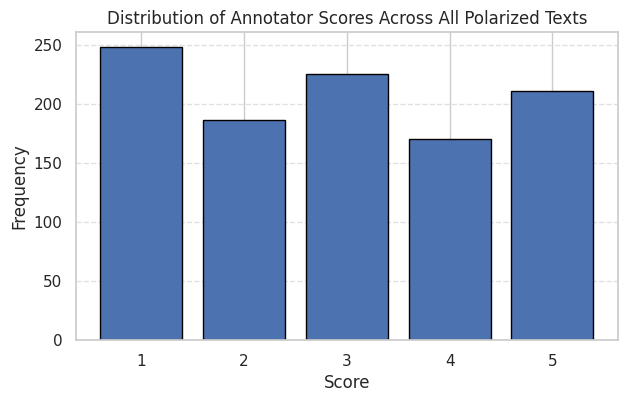

In [ ]:
all_scores = [s for row in polarized_sur["scores"] for s in row]

# Create a histogram
plt.figure(figsize=(7,4))
plt.hist(all_scores, bins=np.arange(0.5, 6.5, 1), edgecolor="black", rwidth=0.8)
plt.xticks([1,2,3,4,5])
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Annotator Scores Across All Polarized Texts")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


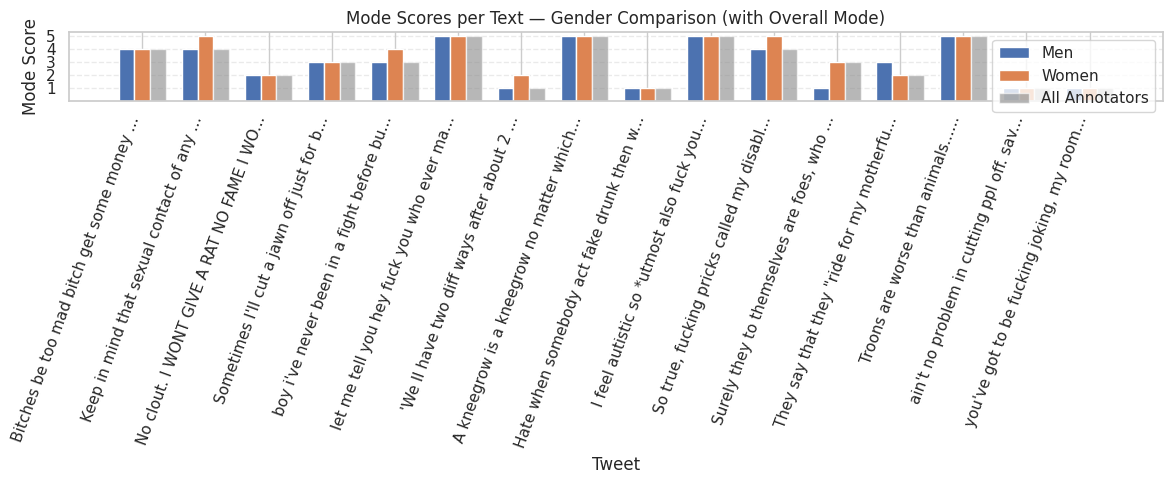

In [ ]:
modes_df["short_tweet"] = modes_df["tweet"].str.slice(0, 40) + "..."

# X axis positions
x = np.arange(len(modes_df))
width = 0.25  # smaller so 3 bars fit cleanly

plt.figure(figsize=(12, 5))

# Bars
plt.bar(x - width, modes_df["mode_men"], width, label="Men", color="#4C72B0")
plt.bar(x, modes_df["mode_women"], width, label="Women", color="#DD8452")
plt.bar(x + width, modes_df["mode_all"], width, label="All Annotators", color="#888888", alpha=0.6)

# Axes and labels
plt.xticks(x, modes_df["short_tweet"], rotation=70, ha="right")
plt.yticks([1, 2, 3, 4, 5])
plt.xlabel("Tweet")
plt.ylabel("Mode Score")
plt.title("Mode Scores per Text — Gender Comparison (with Overall Mode)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


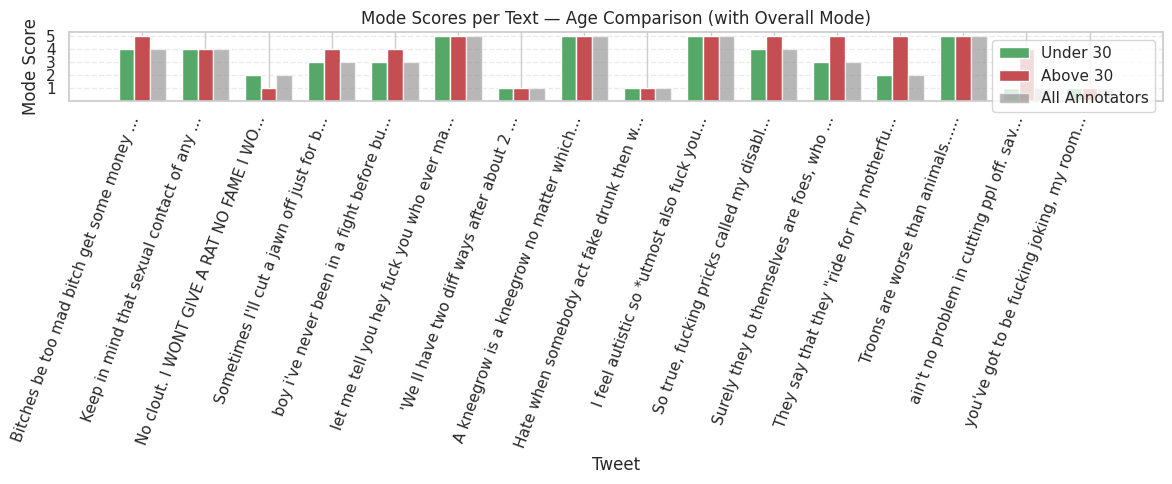

In [ ]:
plt.figure(figsize=(12, 5))

# Adjust width so 3 bars fit well
width = 0.25

# Bars for under 30, over 30, and all annotators
plt.bar(x - width, modes_df["mode_under30"], width, label="Under 30", color="#55A868")
plt.bar(x, modes_df["mode_over30"], width, label="Above 30", color="#C44E52")
plt.bar(x + width, modes_df["mode_all"], width, label="All Annotators", color="#888888", alpha=0.6)

# Axes and labels
plt.xticks(x, modes_df["short_tweet"], rotation=70, ha="right")
plt.yticks([1, 2, 3, 4, 5])
plt.xlabel("Tweet")
plt.ylabel("Mode Score")
plt.title("Mode Scores per Text — Age Comparison (with Overall Mode)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


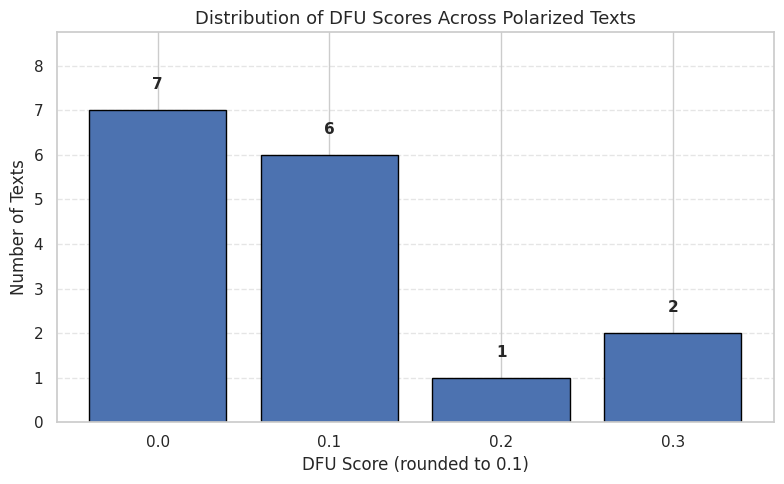

In [ ]:

dfu_rounded = polarized_sur["DFU"].round(1)
dfu_dist = dfu_rounded.value_counts().sort_index()

plt.figure(figsize=(8,5))
bars = plt.bar(dfu_dist.index.astype(str), dfu_dist.values,
               color="#4C72B0", edgecolor="black")

# --- Dynamic label placement ---
max_height = max(dfu_dist.values)
for bar in bars:
    height = bar.get_height()
    offset = max(height * 0.05, 0.4)  # add vertical space proportional to bar height
    plt.text(bar.get_x() + bar.get_width()/2, height + offset,
             f"{int(height)}", ha="center", va="bottom",
             fontsize=11, fontweight="bold")

# --- Add extra top space ---
plt.ylim(0, max_height * 1.25)

plt.title("Distribution of DFU Scores Across Polarized Texts", fontsize=13)
plt.xlabel("DFU Score (rounded to 0.1)")
plt.ylabel("Number of Texts")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

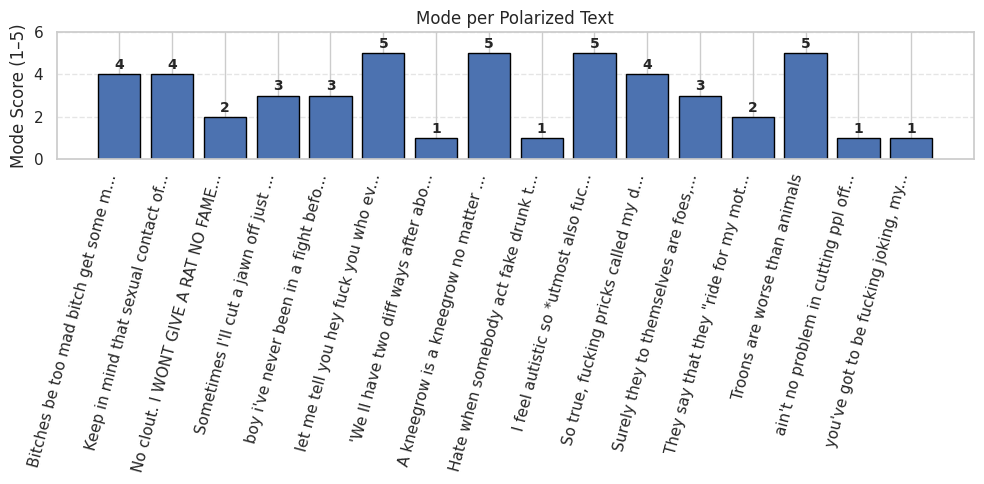

In [ ]:
polarized_sur["mode"] = polarized_sur["scores"].apply(safe_mode)

# Shorten long tweets for readability
labels = [t[:35] + "..." if len(t) > 35 else t for t in polarized_sur["tweet"]]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(polarized_sur)), polarized_sur["mode"],
               color="#4C72B0", edgecolor="black")

# Add text labels above each bar
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{polarized_sur['mode'][i]}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.xticks(range(len(polarized_sur)), labels, rotation=75, ha="right")
plt.ylim(0, 6)
plt.ylabel("Mode Score (1–5)")
plt.title("Mode per Polarized Text")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Overall DFU=0, subgroup DFU>0**

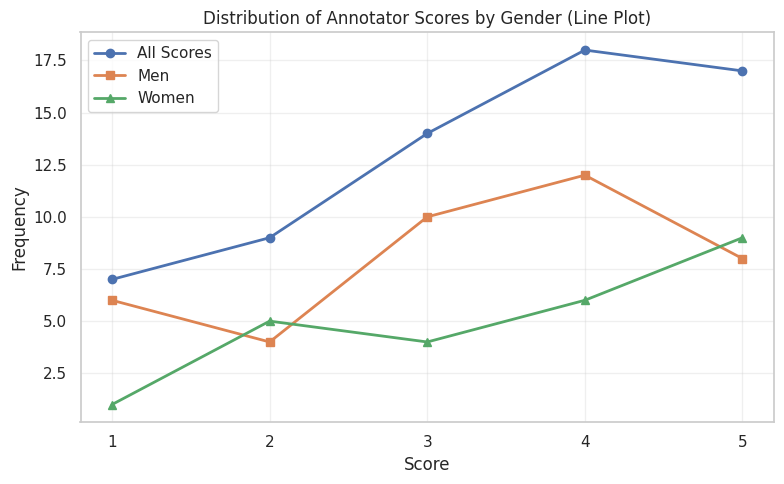

In [ ]:

# Extract lists from your DataFrame row
row = polarized_sur.iloc[1]
scores = row["scores"]
genders = row["annotatorGender"]

# Split by gender
score_men = [s for s, g in zip(scores, genders) if g == "Male"]
score_women = [s for s, g in zip(scores, genders) if g == "Female"]

# Count frequencies for each score (1–5)
score_range = np.arange(1, 6)
count_all = [scores.count(i) for i in score_range]
count_men = [score_men.count(i) for i in score_range]
count_women = [score_women.count(i) for i in score_range]

# Plot as lines
plt.figure(figsize=(8, 5))
plt.plot(score_range, count_all, marker="o", label="All Scores", linewidth=2)
plt.plot(score_range, count_men, marker="s", label="Men", linewidth=2)
plt.plot(score_range, count_women, marker="^", label="Women", linewidth=2)

# Labels and styling
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Annotator Scores by Gender (Line Plot)")
plt.xticks(score_range)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


**Overall DFU=0, subgroup DFU=0**

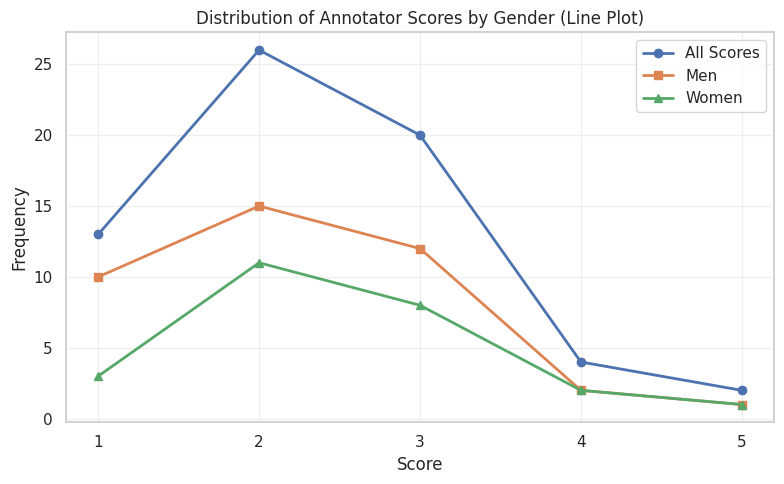

In [ ]:

# Extract lists from your DataFrame row
row = polarized_sur.iloc[2]
scores = row["scores"]
genders = row["annotatorGender"]

# Split by gender
score_men = [s for s, g in zip(scores, genders) if g == "Male"]
score_women = [s for s, g in zip(scores, genders) if g == "Female"]

# Count frequencies for each score (1–5)
score_range = np.arange(1, 6)
count_all = [scores.count(i) for i in score_range]
count_men = [score_men.count(i) for i in score_range]
count_women = [score_women.count(i) for i in score_range]

# Plot as lines
plt.figure(figsize=(8, 5))
plt.plot(score_range, count_all, marker="o", label="All Scores", linewidth=2)
plt.plot(score_range, count_men, marker="s", label="Men", linewidth=2)
plt.plot(score_range, count_women, marker="^", label="Women", linewidth=2)

# Labels and styling
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Annotator Scores by Gender (Line Plot)")
plt.xticks(score_range)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
polarized_sur

,tweet,scores,annotatorGender,annotatorAge,DFU,DFU_men,DFU_women,DFU_under30,DFU_above30,mode
0,Bitches be too mad bitch get some money and mo...,"[5, 3, 4, 4, 4, 2, 1, 4, 4, 4, 5, 1, 3, 4, 2, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.00,0.10,0.00,0.50,4
1,Keep in mind that sexual contact of any kind w...,"[1, 5, 4, 4, 4, 2, 5, 3, 3, 3, 5, 1, 2, 5, 3, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.17,0.11,0.00,0.50,4
2,No clout. I WONT GIVE A RAT NO FAME I WON'T GI...,"[1, 1, 4, 3, 4, 1, 2, 3, 2, 2, 2, 1, 1, 3, 3, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.00,0.00,0.00,0.50,2
3,Sometimes I'll cut a jawn off just for being s...,"[1, 5, 3, 3, 3, 1, 3, 2, 4, 1, 2, 1, 1, 5, 2, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.11,0.09,0.14,0.11,0.33,3
4,boy i've never been in a fight before but i fr...,"[1, 3, 3, 2, 4, 3, 5, 2, 3, 4, 4, 1, 2, 3, 1, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.10,0.20,0.00,0.05,0.33,3
5,let me tell you hey fuck you who ever made thi...,"[5, 5, 5, 5, 5, 4, 5, 5, 4, 5, 5, 1, 5, 5, 4, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.03,0.05,0.06,0.03,0.00,5
6,'We ll have two diff ways after about 2 yrs'-s...,"[1, 3, 1, 1, 3, 2, 2, 2, 2, 1, 1, 5, 2, 2, 5, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.12,0.19,0.00,0.17,0.50,1
7,A kneegrow is a kneegrow no matter which way y...,"[5, 1, 5, 1, 5, 3, 5, 2, 3, 5, 1, 1, 2, 5, 1, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.21,0.24,0.18,0.22,0.20,5
8,Hate when somebody act fake drunk then want yo...,"[1, 1, 1, 2, 1, 1, 1, 1, 4, 2, 1, 5, 1, 4, 1, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.00,0.00,0.08,0.00,1.00,1
9,I feel autistic so *utmost also fuck you and t...,"[5, 1, 5, 5, 5, 4, 3, 4, 2, 4, 3, 2, 3, 5, 1, ...","[Male, Male, Female, Male, Male, Male, Female,...","[Above 30, Under 30, Under 30, Under 30, Under...",0.08,0.14,0.42,0.09,0.00,5


**Overall DFU=0, one subgroup DFU=0**

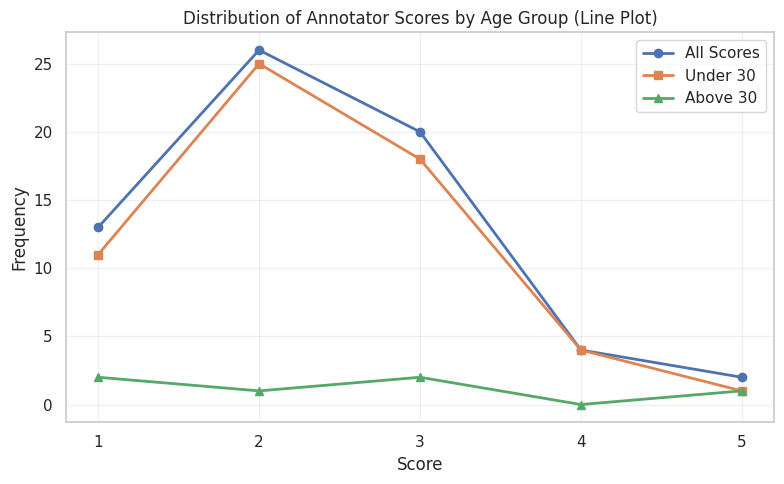

In [ ]:
row = polarized_sur.iloc[2]
scores = row["scores"]
ages = row["annotatorAge"]

# Split by age
score_under30 = [s for s, a in zip(scores, ages) if a == "Under 30"]
score_above30 = [s for s, a in zip(scores, ages) if a == "Above 30"]

# Count frequencies for each score (1–5)
score_range = np.arange(1, 6)
count_all = [scores.count(i) for i in score_range]
count_under30 = [score_under30.count(i) for i in score_range]
count_above30 = [score_above30.count(i) for i in score_range]

# Plot as lines
plt.figure(figsize=(8, 5))
plt.plot(score_range, count_all, marker="o", label="All Scores", linewidth=2)
plt.plot(score_range, count_under30, marker="s", label="Under 30", linewidth=2)
plt.plot(score_range, count_above30, marker="^", label="Above 30", linewidth=2)

# Labels and styling
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("Distribution of Annotator Scores by Age Group (Line Plot)")
plt.xticks(score_range)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()